**WEEK 2 ANALYSTLAB AFRICA INTERNSHIP PROJECT 2- FINTRUST BANK ANALYSIS**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [ ]:
#Load Cleaned Data

WORKBOOK = "FinTrust_Week2_Data_Quality_Workbook.xlsx"

customer = pd.read_excel(WORKBOOK, sheet_name="Customer_Cleaned")
transaction = pd.read_excel(WORKBOOK, sheet_name="Transaction_Cleaned")
transaction["Transaction_DateTime"] = pd.to_datetime(transaction["Transaction_DateTime"])


In [ ]:
print("Customer:", customer.shape)
print("Transaction:", transaction.shape)
customer.head(5)

Customer: (1500, 12)
Transaction: (12000, 12)


,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [ ]:
#Join

df = transaction.merge(customer, on="Customer_ID", how="left", validate="many_to_one")
df["Transaction_DateTime"] = pd.to_datetime(df["Transaction_DateTime"])
df["Txn_Month"] = df["Transaction_DateTime"].dt.to_period("M").astype(str)
df.head(5)


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,...,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status,Txn_Month
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,...,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active,2026-01
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,...,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active,2026-01
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,...,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active,2026-01
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,...,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active,2026-01
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,...,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active,2026-01


In [ ]:
#Outlier Detection

def clean_transactions(tx: pd.DataFrame) -> pd.DataFrame:
    tx = tx.copy()
    tx["Device_Type"] = tx["Device_Type"].fillna("Unknown")
    tx["Location"] = tx["Location"].fillna("Unknown")
    Q1, Q3 = tx["Amount_NGN"].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    tx["Amount_Outlier_Flag"] = tx["Amount_NGN"].apply(
        lambda x: "Yes" if (x < lower or x > upper) else "No")
    return tx

df = clean_transactions(df)


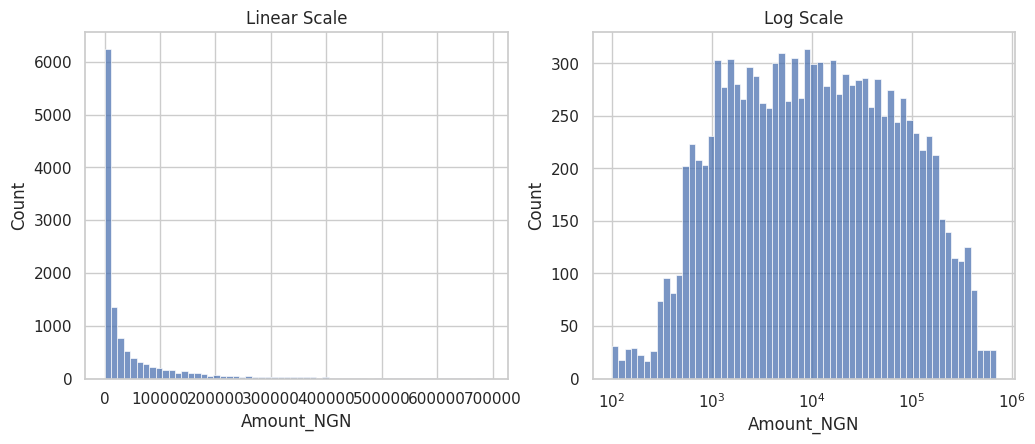

In [ ]:
#Visualization 1: Amount distribution, linear vs log

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Amount_NGN"], bins=60, ax=axes[0])
axes[0].set_title("Linear Scale")
sns.histplot(df["Amount_NGN"], bins=60, ax=axes[1], log_scale=True)
axes[1].set_title("Log Scale")
plt.show()

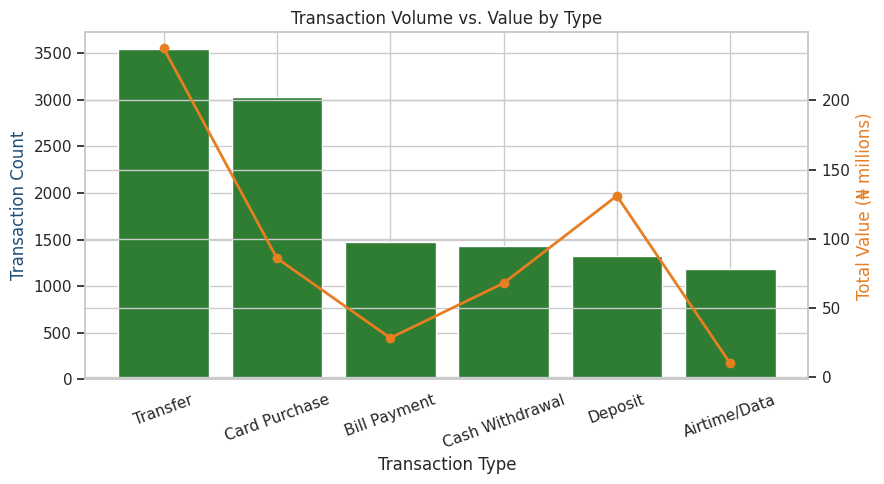

,Txn_Count,Total_Value
Transaction_Type,,
Transfer,3549,2.379167e+08
Card Purchase,3033,8.586341e+07
Bill Payment,1475,2.816365e+07
Cash Withdrawal,1430,6.777236e+07
Deposit,1328,1.309851e+08
Airtime/Data,1185,9.776171e+06


In [ ]:
#Visualization 2: Volume vs Value by type

type_summary = (df.groupby("Transaction_Type")
                  .agg(Txn_Count=("Transaction_ID", "count"),
                       Total_Value=("Amount_NGN", "sum"))
                  .sort_values("Txn_Count", ascending=False))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(type_summary.index, type_summary["Txn_Count"], color="#2E7D32")
ax1.set_ylabel("Transaction Count", color="#1F4E78")
ax1.set_xlabel("Transaction Type")
ax1.tick_params(axis="x", rotation=20)

ax2 = ax1.twinx()
ax2.plot(type_summary.index, type_summary["Total_Value"] / 1e6, color="#E67E22",
         marker="o", linewidth=2)
ax2.set_ylabel("Total Value (₦ millions)", color="#E67E22")

plt.title("Transaction Volume vs. Value by Type")
plt.tight_layout()
plt.savefig("viz2_type_volume_value.png", dpi=110, bbox_inches="tight")
plt.show()

type_summary

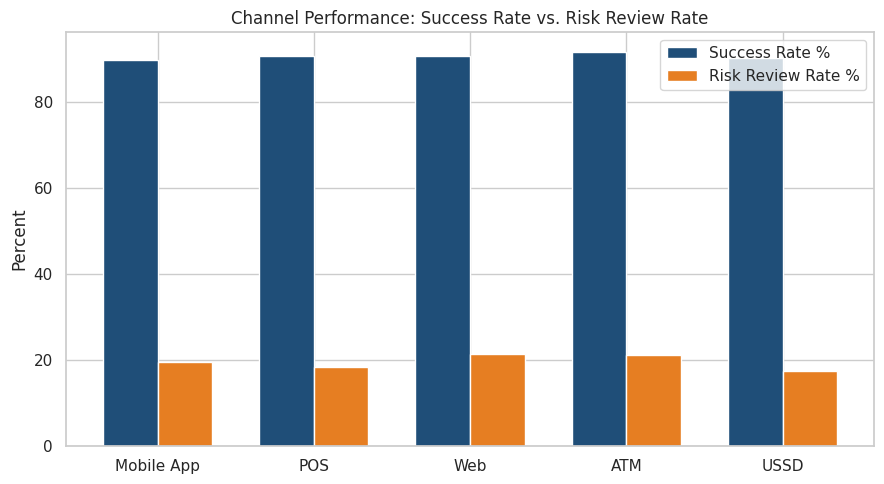

,Total_Txns,Success_Rate,Risk_Review_Rate
Channel,,,
Mobile App,5102,89.75,19.40
POS,2393,90.85,18.35
Web,1869,90.85,21.35
ATM,1747,91.70,21.18
USSD,889,90.33,17.32


In [ ]:
#Visualization 3: Channel success rate vs risk-review rate by channel


channel_summary = (df.groupby("Channel")
                      .agg(Total_Txns=("Transaction_ID", "count"),
                           Success_Rate=("Transaction_Status", lambda s: (s == "Successful").mean() * 100),
                           Risk_Review_Rate=("Risk_Review_Flag", lambda s: (s == "Yes").mean() * 100))
                      .sort_values("Total_Txns", ascending=False))

x = np.arange(len(channel_summary))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, channel_summary["Success_Rate"], width, label="Success Rate %", color="#1F4E78")
ax.bar(x + width/2, channel_summary["Risk_Review_Rate"], width, label="Risk Review Rate %", color="#E67E22")
ax.set_xticks(x)
ax.set_xticklabels(channel_summary.index)
ax.set_ylabel("Percent")
ax.set_title("Channel Performance: Success Rate vs. Risk Review Rate")
ax.legend()
plt.tight_layout()
plt.savefig("viz3_channel_performance.png", dpi=110, bbox_inches="tight")
plt.show()

channel_summary.round(2)


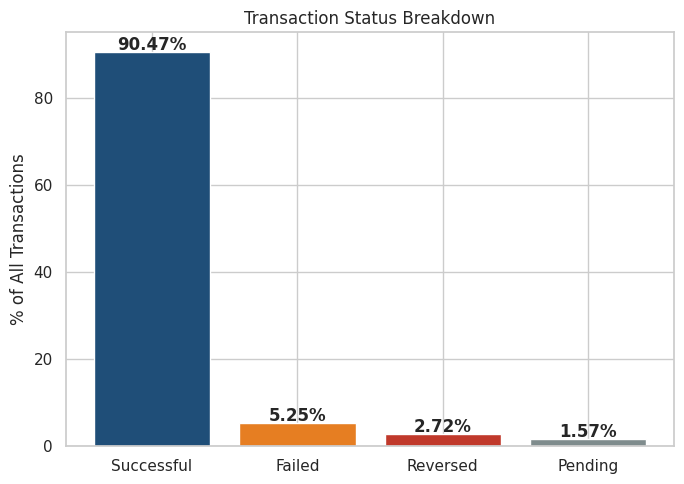

,proportion
Transaction_Status,
Successful,90.47
Failed,5.25
Reversed,2.72
Pending,1.57


In [ ]:
#Visualization 4: Transaction Status Breakdown


status_summary = (df["Transaction_Status"].value_counts(normalize=True) * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#1F4E78", "#E67E22", "#C0392B", "#7F8C8D"]
ax.bar(status_summary.index, status_summary.values, color=colors)
for i, v in enumerate(status_summary.values):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontweight="bold")
ax.set_ylabel("% of All Transactions")
ax.set_title("Transaction Status Breakdown")
plt.tight_layout()
plt.savefig("viz4_status_breakdown.png", dpi=110, bbox_inches="tight")
plt.show()

status_summary

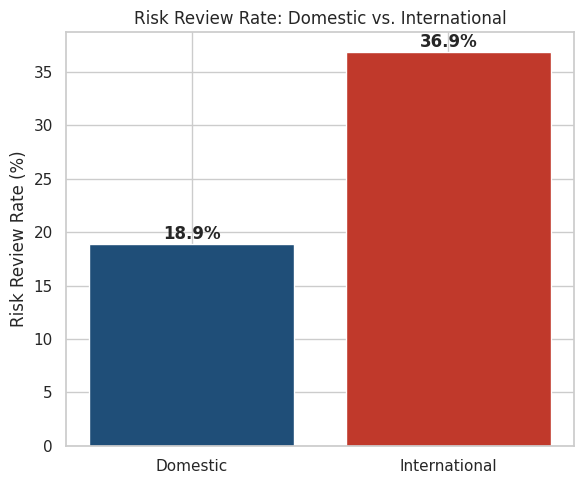

,Total_Txns,Risk_Review_Rate
International_Transaction,,
No,11520,18.88
Yes,480,36.88


In [ ]:
#Visualization 5: Risk-review rate (domestic vs international transactions)


intl_summary = (df.groupby("International_Transaction")
                  .agg(Total_Txns=("Transaction_ID", "count"),
                       Risk_Review_Rate=("Risk_Review_Flag", lambda s: (s == "Yes").mean() * 100))
                  )

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(intl_summary.index.map({"No": "Domestic", "Yes": "International"}),
       intl_summary["Risk_Review_Rate"], color=["#1F4E78", "#C0392B"])
for i, v in enumerate(intl_summary["Risk_Review_Rate"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("Risk Review Rate (%)")
ax.set_title("Risk Review Rate: Domestic vs. International")
plt.tight_layout()
plt.savefig("viz5_international_risk.png", dpi=110, bbox_inches="tight")
plt.show()

intl_summary.round(2)

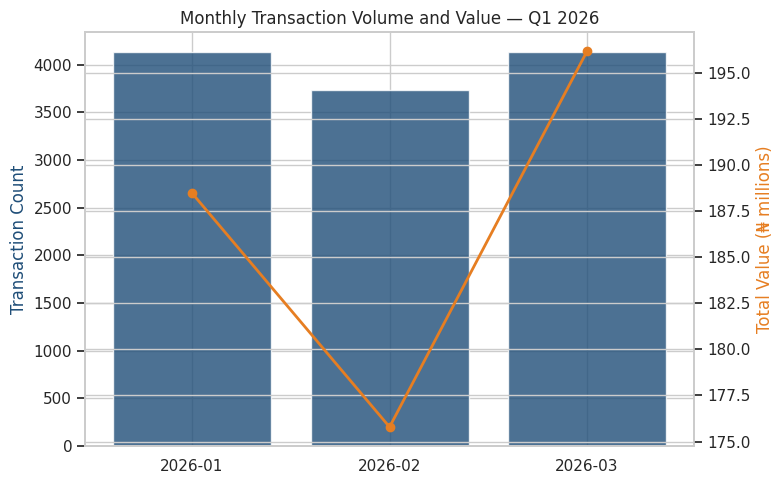

,Txn_Month,Total_Transactions,Total_Value
0,2026-01,4133,1.884894e+08
1,2026-02,3734,1.757869e+08
2,2026-03,4133,1.962010e+08


In [ ]:
#Visualization 6: Monthly transaction volume and value trend


monthly = (df.groupby("Txn_Month")
             .agg(Total_Transactions=("Transaction_ID", "count"),
                  Total_Value=("Amount_NGN", "sum"))
             .reset_index())

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(monthly["Txn_Month"], monthly["Total_Transactions"], color="#1F4E78", alpha=0.8)
ax1.set_ylabel("Transaction Count", color="#1F4E78")
ax2 = ax1.twinx()
ax2.plot(monthly["Txn_Month"], monthly["Total_Value"] / 1e6, color="#E67E22", marker="o", linewidth=2)
ax2.set_ylabel("Total Value (₦ millions)", color="#E67E22")
plt.title("Monthly Transaction Volume and Value — Q1 2026")
plt.tight_layout()
plt.savefig("viz6_monthly_trend.png", dpi=110, bbox_inches="tight")
plt.show()

monthly

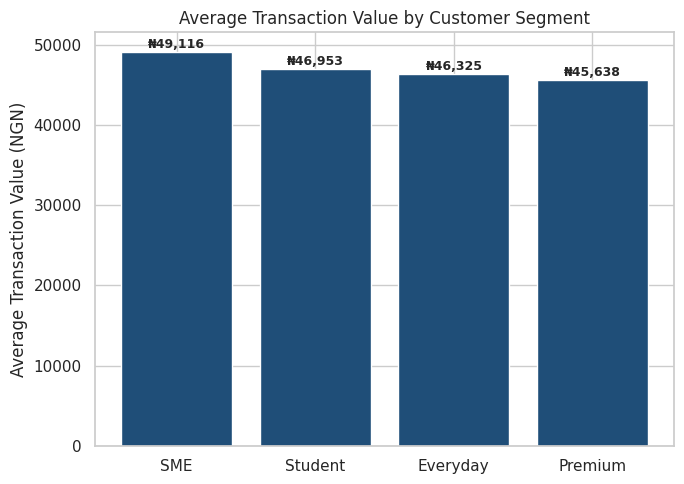

,Amount_NGN
Customer_Segment,
SME,49115.69
Student,46953.20
Everyday,46325.11
Premium,45637.95


In [ ]:
#Visualization 7: Average transaction value by customer segment


segment_avg = (df.groupby("Customer_Segment")["Amount_NGN"]
                 .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(segment_avg.index, segment_avg.values, color="#1F4E78")
for i, v in enumerate(segment_avg.values):
    ax.text(i, v + 500, f"₦{v:,.0f}", ha="center", fontweight="bold", fontsize=9)
ax.set_ylabel("Average Transaction Value (NGN)")
ax.set_title("Average Transaction Value by Customer Segment")
plt.tight_layout()
plt.savefig("viz7_segment_avg_value.png", dpi=110, bbox_inches="tight")
plt.show()

segment_avg.round(2)

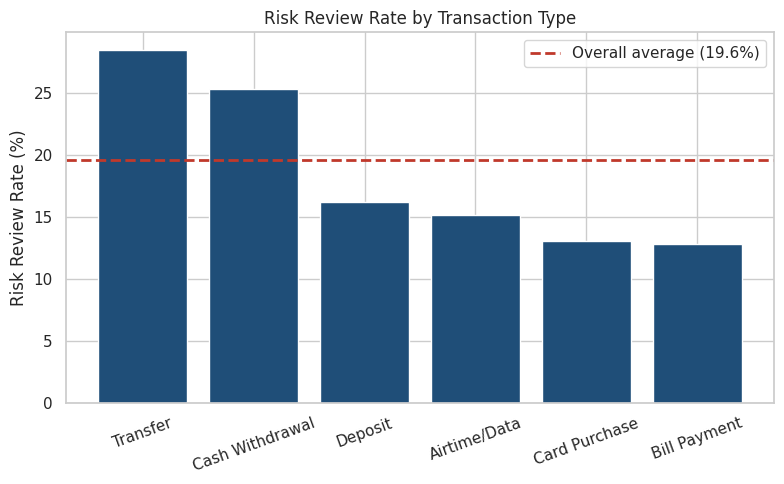

,Risk_Review_Flag
Transaction_Type,
Transfer,28.49
Cash Withdrawal,25.31
Deposit,16.19
Airtime/Data,15.19
Card Purchase,13.02
Bill Payment,12.81


In [ ]:
#Visualization 8: Risk-review rate by

type_risk = (df.groupby("Transaction_Type")["Risk_Review_Flag"]
               .apply(lambda s: (s == "Yes").mean() * 100)
               .sort_values(ascending=False))
overall_rate = (df["Risk_Review_Flag"] == "Yes").mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(type_risk.index, type_risk.values, color="#1F4E78")
ax.axhline(overall_rate, color="#C0392B", linestyle="--", linewidth=2,
           label=f"Overall average ({overall_rate:.1f}%)")
ax.set_ylabel("Risk Review Rate (%)")
ax.set_title("Risk Review Rate by Transaction Type")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig("viz8_risk_by_type.png", dpi=110, bbox_inches="tight")
plt.show()

type_risk.round(2)

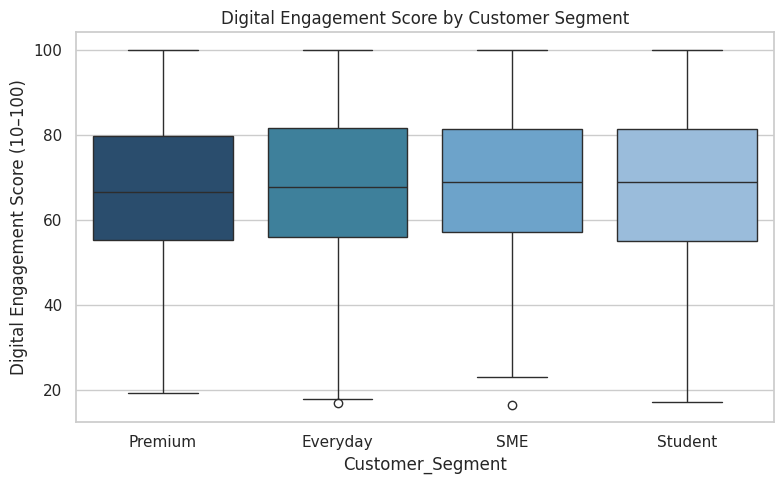

,count,mean,std,min,25%,50%,75%,max
Customer_Segment,,,,,,,,
Everyday,711.0,68.4,17.7,17.1,56.2,67.8,81.6,100.0
Premium,295.0,66.7,16.9,19.3,55.3,66.7,79.8,100.0
SME,216.0,68.3,18.1,16.7,57.2,68.9,81.5,100.0
Student,278.0,67.9,17.4,17.3,55.2,69.1,81.5,100.0


In [ ]:
#Visualization 9: Digital engagement score by customer segment

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=customer, x="Customer_Segment", y="Digital_Engagement_Score",
            hue="Customer_Segment",
            palette=["#1F4E78", "#2E86AB", "#5DA5DA", "#8FBCE6"],
            legend=False, ax=ax)
ax.set_title("Digital Engagement Score by Customer Segment")
ax.set_ylabel("Digital Engagement Score (10–100)")
plt.tight_layout()
plt.savefig("viz9_engagement_by_segment.png", dpi=110, bbox_inches="tight")
plt.show()

customer.groupby("Customer_Segment")["Digital_Engagement_Score"].describe().round(1)

**SUMMARY OF THE FINDINGS**

In [ ]:

findings = pd.DataFrame([
    {
        "Finding": "Transaction amounts are strongly right-skewed",
        "Evidence": f"Mean ₦{df['Amount_NGN'].mean():,.0f} vs. median ₦{df['Amount_NGN'].median():,.0f}",
        "Business Meaning": "Report medians alongside means; treat large transactions as a distinct segment, not noise"
    },
    {
        "Finding": "Transfer dominates volume and value",
        "Evidence": f"{type_summary.loc['Transfer', 'Txn_Count'] / type_summary['Txn_Count'].sum() * 100:.1f}% of transactions, "
                    f"{type_summary.loc['Transfer', 'Total_Value'] / type_summary['Total_Value'].sum() * 100:.0f}% of value",
        "Business Meaning": "Core product to protect for uptime, UX and risk controls"
    },
    {
        "Finding": "Deposit has the highest average ticket size",
        "Evidence": f"Avg ₦{(type_summary['Total_Value'] / type_summary['Txn_Count']).max():,.0f} "
                    f"({(type_summary['Total_Value'] / type_summary['Txn_Count']).idxmax()}) vs. "
                    f"₦{(type_summary['Total_Value'] / type_summary['Txn_Count']).min():,.0f} for the lowest type",
        "Business Meaning": "A small number of deposits move a disproportionate share of money"
    },
    {
        "Finding": "Mobile App has the lowest success rate despite highest volume",
        "Evidence": f"{channel_summary.loc['Mobile App', 'Success_Rate']:.2f}% vs. "
                    f"{channel_summary['Success_Rate'].drop('Mobile App').min():.1f}–{channel_summary['Success_Rate'].drop('Mobile App').max():.1f}% for other channels",
        "Business Meaning": "Worth a root-cause investigation given its scale"
    },
    {
        "Finding": "A meaningful share of transactions are not successful",
        "Evidence": f"{100 - status_summary.get('Successful', 0):.1f}% of transactions are Failed, Reversed or Pending",
        "Business Meaning": "Track Transaction_Success_Rate as a core operational KPI"
    },
    {
        "Finding": "International transactions carry a much higher risk-review rate",
        "Evidence": f"{intl_summary.loc['Yes', 'Risk_Review_Rate']:.1f}% vs. {intl_summary.loc['No', 'Risk_Review_Rate']:.1f}% domestic",
        "Business Meaning": "Strong early candidate feature for the risk model"
    },
    {
        "Finding": "Segment labels don't currently map to transaction size",
        "Evidence": f"Avg value ₦{segment_avg.min():,.0f}–₦{segment_avg.max():,.0f} across all {len(segment_avg)} segments",
        "Business Meaning": "\"Premium\" tier is under-differentiated; check which segment has the highest ticket size"
    },
    {
        "Finding": "Transfer and Cash Withdrawal drive elevated risk-review rates",
        "Evidence": f"Both sit above the {overall_rate:.1f}% overall average risk-review rate",
        "Business Meaning": "Review effort and modelling features should concentrate here first"
    },
])

pd.set_option("display.max_colwidth", None)
display(findings.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

,Finding,Evidence,Business Meaning
0,Transaction amounts are strongly right-skewed,"Mean ₦46,706 vs. median ₦10,306","Report medians alongside means; treat large transactions as a distinct segment, not noise"
1,Transfer dominates volume and value,"29.6% of transactions, 42% of value","Core product to protect for uptime, UX and risk controls"
2,Deposit has the highest average ticket size,"Avg ₦98,633 (Deposit) vs. ₦8,250 for the lowest type",A small number of deposits move a disproportionate share of money
3,Mobile App has the lowest success rate despite highest volume,89.75% vs. 90.3–91.7% for other channels,Worth a root-cause investigation given its scale
4,A meaningful share of transactions are not successful,"9.5% of transactions are Failed, Reversed or Pending",Track Transaction_Success_Rate as a core operational KPI
5,International transactions carry a much higher risk-review rate,36.9% vs. 18.9% domestic,Strong early candidate feature for the risk model
6,Segment labels don't currently map to transaction size,"Avg value ₦45,638–₦49,116 across all 4 segments","""Premium"" tier is under-differentiated; check which segment has the highest ticket size"
7,Transfer and Cash Withdrawal drive elevated risk-review rates,Both sit above the 19.6% overall average risk-review rate,Review effort and modelling features should concentrate here first
